---
execute:
  skip: true
authors:
- name: Ashley Stewart
doi: 10.5281/zenodo.18728759
github: https://github.com/neurodesk/neurodeskedu/blob/main/books/examples/quantitative_imaging/qsmxt.ipynb
edit_url: https://github.com/neurodesk/neurodeskedu/edit/main/books/examples/quantitative_imaging/qsmxt.ipynb
downloads:
- url: /edu/_sources/examples/quantitative_imaging/qsmxt.ipynb
  title: Download source notebook
  filename: qsmxt.ipynb
  static: false
---
# QSMxT

:::{admonition} Reviewed
:class: nd-review-badge nd-review-badge--reviewed

[review issue](<https://github.com/neurodesk/neurodeskedu-reviews/issues/23>) · [@MoniDoerig](<https://github.com/MoniDoerig>)
:::

:::{dropdown} Run this notebook
:class: nd-launch

- [Run in Australia](<https://play.neurodesk.cloud.edu.au/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/qsmxt.ipynb&branch=main>)
- [Run in Europe](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/qsmxt.ipynb&branch=main>)
- [Run in America](<https://play-america.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/qsmxt.ipynb&branch=main>)
- [Run in Global Server 1](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/qsmxt.ipynb&branch=main>)
- [Run in Global Server 2](<https://edu.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/quantitative_imaging/qsmxt.ipynb&branch=main>)
:::



**Author:** Ashley Stewart

**Date:** 25 Aug 2025

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources:
#### Tools included in this workflow

- QSMxT: Stewart AW, Robinson SD, O'Brien K, et al. QSMxT: Robust masking and artifact reduction for quantitative susceptibility mapping. Magnetic Resonance in Medicine. 2022;87(3):1289-1300. [doi:10.1002/mrm.29048](https://doi.org/10.1002/mrm.29048)

- QSMxT: Stewart AW, Bollman S, et al. QSMxT/QSMxT. GitHub; 2022[. https://github.com/QSMxT/QSM](https://github.com/QSMxT/QSMxT)

#### Dataset
- Bollmann, S., & Stewart, A. (2023, August 7). QSM DICOM testdata for QSMxT pipeline. Retrieved from [osf.io/ru43c](https://osf.io/ru43c)

## QSMxT Interactive Notebook

This interactive notebook estimates Quantitative Susceptibility Maps (QSMs) for two gradient-echo (GRE) MRI acquisitions using [QSMxT](https://github.com/QSMxT/QSMxT) provided by the [Neurodesk](https://neurodesk.org) project.

## What is QSM?

QSM is a form of quantitative MRI (qMRI) that estimates the magnetic susceptibility distribution across an imaged object. Magnetic susceptibility is the degree to which a material becomes magnetised by an external magnetic field. Major contributors to susceptibility include iron, calcium, and myelin, with the susceptibility of water typically approximating a zero-reference, though it is slightly diamagnetic. Read more about QSM [here](https://doi.org/10.1002/mrm.25358).

## What is QSMxT?

[QSMxT](https://qsmxt.github.io) is a suite of tools for building and running automated pipelines for QSM that:

- is available open-source without any licensing required;
- is distributed as a software container making it straightforward to access and install (Neurodesk!)
- scales its processing to execute across many acquisitions through jobs parallelisation (using multiple processors or HPCs) provided by [Nipype](https://nipype.readthedocs.io);
- automates steps that usually require manual intervention and scripting, including:
  - DICOM to [BIDS](https://bids-specification.readthedocs.io/en/stable/index.html) conversion;
  - QSM reconstruction using a range of algorithms;
  - segmentation using [FastSurfer](https://github.com/Deep-MI/FastSurfer);
  - group space generation using [ANTs](https://github.com/ANTsX/ANTs);
  - export of susceptibility statistics by subject and region of interest (ROI) to CSV.

![QSMxT output](qsmxt_assets/image.png)


## How do I access QSMxT?

There are a few ways you can access QSMxT:

 - **This notebook**: You can access QSMxT in this notebook right now!
   - If you are running this on a Neurodesk Play instance, you can upload your own data into the sidebar via drag-and-drop.
 - **Neurodesktop**: QSMxT is in the applications menu of Neurodesktop.
   - On Neurodesk Play, upload your own data into the desktop via drag-and-drop.
   - On a local install of Neurodesk, bring any necessary files into the shared `~/neurodesktop-storage` directory
 - **Local install**: QSMxT can also be installed via the [Docker container](https://qsmxt.github.io/QSMxT/installation)
 - **HPC install**: QSMxT can also be installed via the [Singularity container](https://qsmxt.github.io/QSMxT/installation) for use on HPCs

## Download example DICOMs

Here, we download some example DICOMs from our OSF repository for QSMxT.

These data include GRE and T1-weighted acquisitions for one subject (duplicated to act as two subjects).

In [2]:
!osf -p ru43c clone . > /dev/null 2>&1
!tar xf osfstorage/dicoms-unsorted.tar
!rm -rf osfstorage/
!tree dicoms-unsorted | head
!echo -e "...\nThere are `ls dicoms-unsorted | wc -l` unsorted DICOMs in ./dicoms-unsorted/"

dicoms-unsorted
├── MR.1.1.dcm
├── MR.1.10.dcm
├── MR.1.100.dcm
├── MR.1.101.dcm
├── MR.1.102.dcm
├── MR.1.103.dcm
├── MR.1.104.dcm
├── MR.1.105.dcm
├── MR.1.106.dcm


...
There are 1216 unsorted DICOMs in ./dicoms-unsorted/


## Load QSMxT

To load QSMxT inside a notebook, we can use the available module system:

In [3]:
import module
await module.load('qsmxt/8.1.1')
!qsmxt --version

[INFO]: QSMxT v8.1.1


## Data standardisation

QSMxT requires input data to conform to the [Brain Imaging Data Structure (BIDS)](https://bids.neuroimaging.io/).

Luckily, QSMxT also provides scripts that can convert unorganised NIfTI or DICOM images to BIDS. If you are using NIfTI images and do not have DICOMs, see [nifti-convert](https://qsmxt.github.io/QSMxT/using-qsmxt/data-preparation#nifti-to-bids).

## Convert DICOM to BIDS

The DICOM to BIDS conversion must identify which series should be used for QSM reconstruction (e.g. MEGRE), and which series should be used for segmentation (T1-weighted). Because this information is not stored in the DICOM header in a standardised way, it can only be estimated based on other fields, or the user must identify series themselves.

If QSMxT is run interactively, the user will be prompted to identify the relevant series. However, because we are running QSMxT in a notebook, we disable the interactivity using `--auto_yes` and allow QSMxT to guess the intended purpose of each acquisition. In this case, it makes the right guess:

In [4]:
!dicom-convert dicoms-unsorted bids --auto_yes

/opt/miniconda-4.12.0/lib/python3.8/site-packages/dicompare/io.py:30: UserWarning: The DICOM readers are highly experimental, unstable, and only work for Siemens time-series at the moment
Please use with caution.  We would be grateful for your help in improving them
  from nibabel.nicom.csareader import get_csa_header


[INFO]: Running QSMxT 8.1.1
[INFO]: Command: /opt/miniconda-4.12.0/bin/dicom-convert dicoms-unsorted bids --auto_yes
[INFO]: Python interpreter: /opt/miniconda-4.12.0/bin/python3.8
Loading DICOM files:   0%|                             | 0/1216 [00:00<?, ?it/s]

Loading DICOM files:   1%|▏                    | 9/1216 [00:00<00:14, 80.96it/s]

Loading DICOM files:   2%|▎                   | 21/1216 [00:00<00:12, 97.19it/s]

Loading DICOM files:   3%|▌                  | 32/1216 [00:00<00:11, 100.33it/s]

...

Conversion required 0.116779 seconds (0.116740 for core code).


[INFO]: Scanning for multi-coil data to merge...


[INFO]: Scanning for multi-coil runs to combine...


[INFO]: Checking for complex or polar data requiring fixing...
Loading NIfTIs: 100%|█████████████████████████| 46/46 [00:00<00:00, 1735.26it/s]


[INFO]: Finished


In [5]:
!tree bids

bids
├── derivatives
│   ├── qsmxt-2026-08-27-224935
│   │   ├── command.txt
│   │   ├── pypeline.log
│   │   ├── qsmxt.log
│   │   ├── references.txt
│   │   ├── settings.json
│   │   ├── sub-1
│   │   │   └── ses-20170705
│   │   │       ├── anat
│   │   │       │   ├── sub-1_ses-20170705_acq-acqmp2ragehighres0p5isoslab_T1w_space-orig_dseg.nii
│   │   │       │   ├── sub-1_ses-20170705_acq-acqmp2ragehighres0p5isoslab_T1w_space-qsm_dseg.nii
│   │   │       │   ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_Chimap.json
│   │   │       │   ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_Chimap.nii
│   │   │       │   ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_space-orig_dseg.nii
│   │   │       │   └── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_space-qsm_dseg.nii
│   │   │       └── extra_data
│   │   │           ├── sub-1_ses-20170705_acq-acqmp2ragehighres0p5isoslab_T1w_desc-t1w-to-qsm_transform.mat
│   │   │           ├── sub-1_ses-20170705_acq-acqqsmp21

## Inspect input data

Here we define a function we will use to visualise NIfTI images so we can view some of the input data:

In [6]:
%%capture
!pip install seaborn==0.13.2 numpy==2.3.5 nibabel==5.3.3 pandas==2.3.3 nilearn==0.13.1

In [7]:
from glob import glob
from matplotlib import pyplot as plt
import numpy as np
import nibabel as nib

def show_nii(nii_path, title=None, figsize=(4,5), cmap='gray', **imshow_args):
    # load data\n",
    data_1 = nib.load(nii_path).get_fdata()

    # get middle slices\n",
    slc_data1 = np.rot90(data_1[np.shape(data_1)[0]//2,:,:])
    slc_data2 = np.rot90(data_1[:,np.shape(data_1)[1]//2,:])
    slc_data3 = np.rot90(data_1[:,:,np.shape(data_1)[2]//2])

    # show slices\n",
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)
    if title: plt.suptitle(title)

    axes[0].imshow(slc_data1, cmap=cmap, **imshow_args)
    axes[1].imshow(slc_data2, cmap=cmap, **imshow_args)
    axes[2].imshow(slc_data3, cmap=cmap, **imshow_args)

    axes[0].axis('off')
    axes[1].axis('off')
    axes[2].axis('off')

    fig.tight_layout()
    fig.subplots_adjust(top=1.55)
    plt.show()

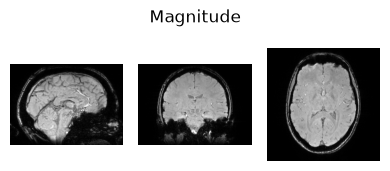

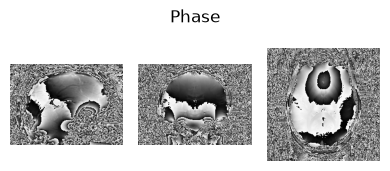

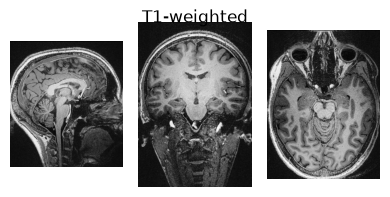

In [8]:
show_nii(glob("bids/sub-*/ses-*/anat/*mag*T2starw*nii*")[0], title="Magnitude", vmax=500)
show_nii(glob("bids/sub-*/ses-*/anat/*phase*T2starw*nii*")[0], title="Phase")
show_nii(glob("bids/sub-*/ses-*/anat/*T1w*nii*")[0], title="T1-weighted")

##### Interactive Display using Niivue


In [9]:
from ipyniivue import NiiVue

nv_T1 = NiiVue()
nv_T1.load_volumes([{"path": glob("bids/sub-*/ses-*/anat/*T1w*nii*")[0]}])
nv_T1

[HF-patcher] sub-2: path → url


## Run QSMxT

We are now ready to run QSMxT! We will generate susceptibility maps and segmentations, and export analysis CSVs to file.

The usual way of running QSMxT is to use `qsmxt bids_dir`. This will launch an interactive command-line interface (CLI) to setup your desired pipelines. However, since we are running this in a notebook, we need to use command-line arguments to by-pass the interface and execute a pipeline.

But first, let's consider our pipeline settings. For QSM reconstruction, QSMxT provides a range of sensible defaults fit for different purposes. We can list the premade QSM pipelines using `--list_premades`. For the full pipeline details used for each premade pipeline, see [qsm_pipelines.json](https://github.com/QSMxT/QSMxT/blob/main/qsmxt/qsm_pipelines.json).

In [10]:
!qsmxt --list_premades

=== Premade pipelines ===
default: Default QSMxT settings (GRE; assumes human brain)
gre: Applies suggested settings for 3D-GRE images
epi: Applies suggested settings for 3D-EPI images (assumes human brain)
bet: Applies a traditional BET-masking approach (artefact reduction unavailable; assumes human brain)
fast: Applies a set of fast algorithms
body: Applies suggested settings for non-brain applications
nextqsm: Applies suggested settings for running the NeXtQSM algorithm (assumes human brain)
[INFO]: Finished


For this demonstration, we will go with the `fast` pipeline. To export segmentations and analysis results, we will use `--do_segmentation` and `--do_analysis`. The `--auto_yes` option avoid the interactive CLI interface that cannot be used in a notebook:

In [11]:
!qsmxt bids \
    --premade fast \
    --do_qsm \
    --do_segmentation \
    --do_analysis \
    --auto_yes

[INFO]: QSMxT v8.1.1
[INFO]: Python interpreter: /opt/miniconda-4.12.0/bin/python3.8
[INFO]: Command: qsmxt /home/jovyan/workspace/books/examples/quantitative_imaging/bids --premade 'fast' --do_qsm --do_segmentation --do_analysis --auto_yes


[WARNING]: Pipeline is NOT guidelines compliant (see https://doi.org/10.1002/mrm.30006):; Phase-quality-based masking recommended
[INFO]: Available memory: 54.351 GB


[INFO]: Creating QSMxT workflow for sub-1.ses-20170705.acq-acqmp2ragehighres0p5isoslab.T1w...


[INFO]: Creating QSMxT workflow for sub-1.ses-20170705.acq-acqqsmp21mmisote20.T2starw...
[INFO]: Creating QSMxT workflow for sub-2.ses-20170705.acq-acqmp2ragehighres0p5isoslab.T1w...
[INFO]: Creating QSMxT workflow for sub-2.ses-20170705.acq-acqqsmp21mmisote20.T2starw...


[INFO]: Running using MultiProc plugin with n_procs=16


...

260827-23:28:17,827 nipype.workflow INFO:
	 [Job 73] Completed (qsmxt-workflow.sub-2.ses-20170705.qsm_acq-acqqsmp21mmisote20_T2starw.nibabel_numpy_analyse-qsm).
260827-23:28:17,829 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 56.51/56.51, Free processors: 16/16.


260827-23:28:17,884 nipype.workflow INFO:
	 [Node] Outdated cache found for "qsmxt-workflow.sub-2.ses-20170705.qsm_acq-acqqsmp21mmisote20_T2starw.copyfile".
260827-23:28:17,886 nipype.workflow INFO:
	 [Node] Setting-up "qsmxt-workflow.sub-2.ses-20170705.qsm_acq-acqqsmp21mmisote20_T2starw.copyfile" in "/home/jovyan/workspace/books/examples/quantitative_imaging/bids/derivatives/workflow/qsmxt-workflow/sub-2/ses-20170705/qsm_acq-acqqsmp21mmisote20_T2starw/copyfile".
260827-23:28:17,887 nipype.workflow INFO:
	 [Node] Outdated cache found for "qsmxt-workflow.sub-2.ses-20170705.qsm_acq-acqqsmp21mmisote20_T2starw.copyfile".
260827-23:28:17,889 nipype.workflow INFO:
	 [Node] Executing "copyfile" <qsmxt.interfaces.nipype_interface_copyfile.DynamicCopyFiles>


260827-23:28:18,62 nipype.workflow INFO:
	 [Node] Finished "copyfile", elapsed time 0.172158s.


260827-23:28:19,829 nipype.workflow INFO:
	 [Job 75] Completed (qsmxt-workflow.sub-2.ses-20170705.qsm_acq-acqqsmp21mmisote20_T2starw.copyfile).
260827-23:28:19,831 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 0 jobs ready. Free memory (GB): 56.51/56.51, Free processors: 16/16.


[INFO]: Warnings occurred!
[INFO]: Finished


## View results

Let's have a look at the generated `qsm` folder:

In [12]:
!tree bids/derivatives/qsmxt-*-* --dirsfirst

bids/derivatives/qsmxt-2026-08-27-224935
├── sub-1
│   └── ses-20170705
│       ├── anat
│       │   ├── sub-1_ses-20170705_acq-acqmp2ragehighres0p5isoslab_T1w_space-orig_dseg.nii
│       │   ├── sub-1_ses-20170705_acq-acqmp2ragehighres0p5isoslab_T1w_space-qsm_dseg.nii
│       │   ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_Chimap.json
│       │   ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_Chimap.nii
│       │   ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_space-orig_dseg.nii
│       │   └── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_space-qsm_dseg.nii
│       └── extra_data
│           ├── sub-1_ses-20170705_acq-acqmp2ragehighres0p5isoslab_T1w_desc-t1w-to-qsm_transform.mat
│           ├── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_desc-t1w-to-qsm_transform.mat
│           └── sub-1_ses-20170705_acq-acqqsmp21mmisote20_T2starw_qsm-analysis.csv
├── sub-2
│   └── ses-20170705
│       ├── anat
│       │   ├── sub-2_ses-20170705_acq-acqmp2ragehigh

The `references.txt` file contains a list of all the algorithms used and relevant citations:

In [13]:
!cat bids/derivatives/qsmxt-*-*/references.txt

== References ==

 - QSMxT: Stewart AW, Robinson SD, O'Brien K, et al. QSMxT: Robust masking and artifact reduction for quantitative susceptibility mapping. Magnetic Resonance in Medicine. 2022;87(3):1289-1300. doi:10.1002/mrm.29048

 - QSMxT: Stewart AW, Bollman S, et al. QSMxT/QSMxT. GitHub; 2022. https://github.com/QSMxT/QSMxT

 - Python package - Nipype: Gorgolewski K, Burns C, Madison C, et al. Nipype: A Flexible, Lightweight and Extensible Neuroimaging Data Processing Framework in Python. Frontiers in Neuroinformatics. 2011;5. Accessed April 20, 2022. doi:10.3389/fninf.2011.00013

 - Brain extraction: Smith SM. Fast robust automated brain extraction. Human Brain Mapping. 2002;17(3):143-155. doi:10.1002/hbm.10062

 - Brain extraction: Liangfu Chen. liangfu/bet2 - Standalone Brain Extraction Tool. GitHub; 2015. https://github.com/liangfu/bet2

 - Unwrapping algorithm - ROMEO: Dymerska B, Eckstein K, Bachrata B, et al. Phase unwrapping with a rapid opensource minimum spanning tree a

## QSM results
Let's view one of the QSM results:

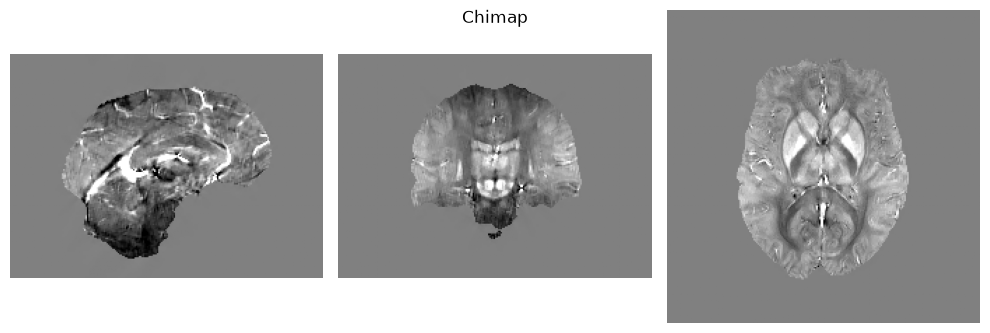

In [14]:
show_nii(glob("bids/derivatives/qsmxt-*/sub-*/ses-*/anat/*Chimap.nii*")[0], title="Chimap", figsize=(10,8), cmap='gray', vmin=-0.1, vmax=0.1)

## Segmentations

Segmentations are generated in both the QSM space and the T1-weighted space. Transformations are also made available.

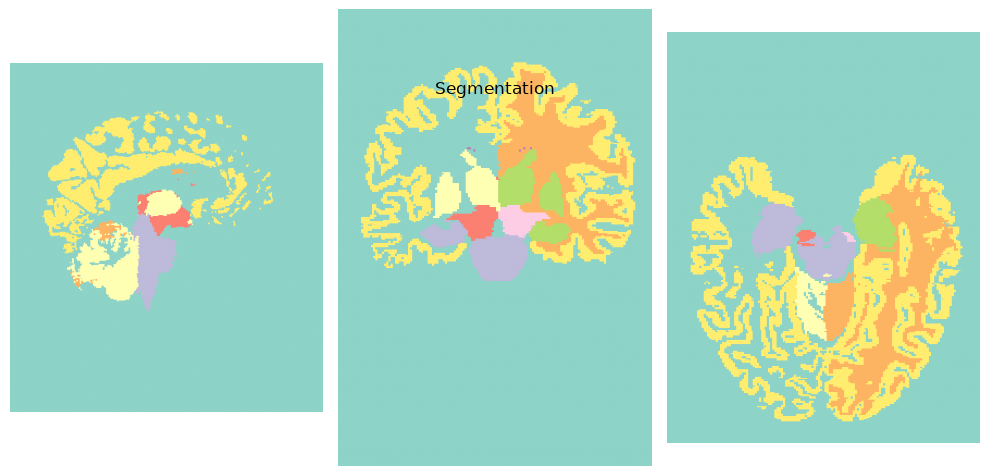

In [15]:
show_nii(glob("bids/derivatives/qsmxt-*/sub-*/ses-*/anat/*qsm_dseg.nii*")[0], title="Segmentation", figsize=(10,8), cmap='Set3', vmin=0, vmax=96)

## Analysis CSVs

CSV files have been exported containing susceptibility values in regions of interest for each subject.

Here we will load the CSVs, inspect the data and generate figures:

In [16]:
# import modules
import pandas as pd
import seaborn as sns

The raw CSV files use names from FreeSurfer as exported by FastSurfer. The full list of regions is available [here](https://github.com/QSMxT/QSMxT/blob/main/qsmxt/aseg_labels.csv).

In [17]:
pd.read_csv(glob("bids/derivatives/qsmxt-*-*/sub*/ses*/extra*/*.csv")[0])

,roi,num_voxels,min,max,median,mean,std
0,3rd-Ventricle,593,-0.234321,0.124799,-0.018955,-0.022252,0.034571
1,4th-Ventricle,1541,-0.126117,0.052944,-0.045795,-0.045746,0.030755
2,Brain-Stem,18699,-0.279382,0.102235,-0.045174,-0.041312,0.028731
3,CSF,864,-1.393693,0.945752,0.027255,0.031507,0.142815
4,Left-Accumbens-area,520,-0.141920,0.128334,0.023897,0.021386,0.031151
...,...,...,...,...,...,...,...
91,ctx-rh-superiorfrontal,29677,-0.133274,0.251870,-0.003990,-0.009347,0.024487
92,ctx-rh-superiorparietal,12053,-0.084225,0.306628,-0.015600,-0.014690,0.022030
93,ctx-rh-superiortemporal,16318,-0.090982,0.248737,0.006749,0.012938,0.024256
94,ctx-rh-supramarginal,12050,-0.056940,0.239688,0.018507,0.019464,0.022786


We will select a subset of these ROIs and give them more readable names:

In [18]:
# define regions of interest
# see https://github.com/QSMxT/QSMxT/blob/main/qsmxt/aseg_labels.csv for a full list
rois = { 
    "Thalamus" : [9, 10, 48, 49],
    "Pallidum" : [12, 13, 52, 53],
    "Caudate" : [11, 50],
    "Putamen" : [12, 51],
    "Brain stem" : [16],
    "CSF" : [24, 122, 257, 701],
    "White matter" : [2, 7, 41, 46, 177]
}
roi_names = { value: key for key in rois for value in rois[key] }
roi_ids = [value for roi in rois.values() for value in roi]

In [19]:
# load a reconstruction
qsm_img = nib.load(glob("bids/derivatives/qsmxt-*-*/sub*/ses*/anat*/*Chimap.nii*")[0])
seg_img = nib.load(glob("bids/derivatives/qsmxt-*-*/sub*/ses*/anat*/*space-qsm*dseg.nii*")[0])

In [20]:
from nilearn.image import resample_to_img
# Resample the segmentation image to match the QSM image space
# Use 'nearest' interpolation to preserve the integer labels of the segmentation.
print("Resampling segmentation to match QSM dimensions...")
seg_resampled_img = resample_to_img(seg_img, qsm_img, interpolation='nearest')
print("Resampling complete.")

Resampling segmentation to match QSM dimensions...


Resampling complete.


In [21]:
# Get data arrays
qsm = qsm_img.get_fdata()
seg = seg_resampled_img.get_fdata()

In [22]:
# Check shapes to confirm they match
print(f"Shape of QSM data: {qsm.shape}")
print(f"Shape of resampled segmentation data: {seg.shape}")
if qsm.shape != seg.shape:
    raise ValueError("FATAL: Shapes not match after resampling. Check your input files.")

Shape of QSM data: (224, 224, 160)
Shape of resampled segmentation data: (224, 224, 160)


In [23]:
# --- Flatten the arrays now that they have the same dimensions ---
qsm = qsm.flatten()
seg = seg.flatten()

In [24]:
# retain only the rois
qsm = qsm[np.isin(seg, roi_ids)]
seg = seg[np.isin(seg, roi_ids)]

In [25]:
# convert to a dataframe for plotting purposes
seg = pd.Series(seg).map(roi_names)
data = pd.DataFrame({ 'qsm' : qsm, 'seg' : seg })

In [26]:
# summarise data by region including the average and standard deviation
data.groupby('seg')['qsm'].agg(['mean', 'std']).sort_values('mean').round(decimals=3)

,mean,std
seg,,
CSF,-0.040,0.030
Thalamus,-0.010,0.022
Brain stem,-0.004,0.017
Putamen,-0.003,0.012
White matter,-0.003,0.027
Caudate,-0.002,0.013
Pallidum,-0.001,0.008


In [27]:
medians = data.groupby('seg')['qsm'].median().sort_values()
order = medians.index

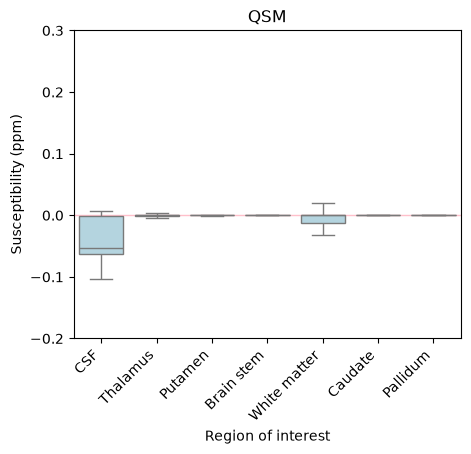

In [28]:
# plot
fig, ax = plt.subplots(figsize=(5,4))
sns.boxplot(data=data, y='qsm', x='seg', fliersize=0, color='lightblue', order=order, ax=ax)
ax.set_xticks(range(len(ax.get_xticks())))  # Set tick positions explicitly
ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation=45)
ax.set_ylim(-0.2, 0.3)
ax.axhline(y=0, color='pink', linestyle='-', linewidth=1, zorder=-1)
ax.set_xlabel("Region of interest")
ax.set_ylabel("Susceptibility (ppm)")
ax.set_title("QSM")
plt.show()

#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [29]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-08-27T23:28:25.335722+00:00

Python implementation: CPython
Python version       : 3.13.14
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 6.8.0-111-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit

ipyniivue : 2.4.4
json      : 2.0.9
matplotlib: 3.11.0
nibabel   : 5.3.3
nilearn   : 0.13.1
numpy     : 2.3.5
pandas    : 2.3.3
seaborn   : 0.13.2

Neurodesktop version: 2026-07-11
